In [ ]:
import pickle
import os
import random
import glob
import json
import math
import numpy as np
import matplotlib.pyplot as plt
import h5py
import datetime
import scipy.io
import scipy.signal as signal
from itertools import chain
from scipy.signal import correlate, correlation_lags, fftconvolve
from matplotlib import rc
rc('xtick', labelsize=14)
rc('ytick', labelsize=14)

In [ ]:
datestr = "04-09-2026_12-09-38"
pickle_filename = "measurements_" + datestr + ".pickle"
print("Reading pickle: " + pickle_filename)
with open(pickle_filename, "rb") as f:
    nodenames, rxrepeat, total_power, single_tx_power = pickle.load(f)

Reading pickle: measurements_04-09-2026_12-09-38.pickle


The data structure for the received power measurements is `total_power`

- The list is indexed by `txgroup_num`, an integer that represents the list of transmitters that are simultaneously TXing.
- Consider that each node can be be a tx, or not. So listing the names in alphabetical order, there is a num_nodes-length list of binary numbers. txgroup_num is the decimal equivalent of that binary list, with the first binary number is the MSB
- So total_power[i] for a decimal number i references all received power measurmeents when tx group i (but in binary) is transmitting.

`total_power[i]` references a dictionary: `total_power[i][receiver_name]` is the received power measured at `receiver_name`:
- `receiver_name` is a string. The value output is a list of real-valued power measurements.
- `total_power[i][receiver_name][j]` is the jth measurement. There are `rxrepeat` measurements per receiver.
- The real-valued power measurement is averaged over the period of the overlap of all transmissions


In [ ]:
def convert_txname_to_int(txname, txlocs):

  # Convert txname to a binary array, y. Element i, y[i]==1 if txname contains the string txlocs[i].
  # Convert binary array y to a decimal value, first element is the most-significant bit
  numnodes = len(txlocs)
  txgroup_num = 0
  txes_in_group = 0
  for i in range(numnodes):
    if (txlocs[i] in txname):
      txgroup_num += 2**((numnodes-1) - i)
      txes_in_group += 1

  return txgroup_num

# Test code for the convert_txname_to_int() function
txloc = '0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210'
print('txloc =', txloc)
print('Converts to integer ', str(convert_txname_to_int(txloc, nodenames)))

txloc = 0+cnode-ebc-dd-b210+cnode-guesthouse-dd-b210+cnode-mario-dd-b210+cnode-moran-dd-b210
Converts to integer  60


In [ ]:
def convert_int_to_tflist(txgroup_num, txlocs):

  # Init the return vector
  tflist = np.empty(len(txlocs), dtype=np.int8)

  # Convert the decimal integer txgroup_num to binary string, length txlocs
  # tflist[i] == True if that node is TXing, according to txgroup_num
  b = format(txgroup_num, str(len(txlocs)) + 'b')
  for i, char in enumerate(b):
    tflist[i] = (char == '1')

  return tflist

# Test code
print(convert_int_to_tflist(15, nodenames))

[0 0 1 1 1 1]


In [ ]:
# Here's how to access the measurements.

# Let's assume EBC and USTAR are transmitting and mario is receiving
txstring = '0+cnode-ebc-dd-b210+cnode-ustar-dd-b210'
rxstring = 'cnode-mario-dd-b210'

# Get the txgroup_num from the string
txgroup_num = convert_txname_to_int(txstring, nodenames)
print('txgroup_num =', txgroup_num)

# Get the measurements for the receiver
print(total_power[txgroup_num][rxstring])

tflist = convert_int_to_tflist(txgroup_num, nodenames)
print(np.where(tflist>0)[0])
tx_node_names = [nodenames[x] for x in np.where(tflist>0)[0]]
print(tx_node_names)

txgroup_num = 34
[0.00020308 0.0002143  0.00019807 0.00020561]
[0 4]
['cnode-ebc-dd-b210', 'cnode-ustar-dd-b210']


In [ ]:
# Compute the average noise power for each node in nodename

# Initialize a dictionary
noise_power = {}
noTx_group_num = convert_txname_to_int("0", nodenames)
print("Tx_group_num for noise measurement is " + str(noTx_group_num))
for node in nodenames:
  noise_power[node] = np.average(total_power[noTx_group_num][node])
print(noise_power)

Tx_group_num for noise measurement is 0
{'cnode-ebc-dd-b210': np.float64(0.00024270514859381367), 'cnode-guesthouse-dd-b210': np.float64(0.00019286037477286302), 'cnode-mario-dd-b210': np.float64(0.00016722179134376347), 'cnode-moran-dd-b210': np.float64(0.00017794846280594356), 'cnode-ustar-dd-b210': np.float64(9.498988592895331e-05), 'cnode-wasatch-dd-b210': np.float64(0.00022120072080724642)}


In [ ]:
def printNoisePower(noise_power, nodenames, dB=False):

  # Use just the node name in the column title, not the "cnode-" or the "-dd-b210".
  # That means remove 14 chars from each nodename. Add one for a extra space.
  colwidth = max([len(x) for x in nodenames]) - 14 + 1
  colformatstr = '{: >' + str(colwidth) + '}'

  # Format the measurement values # decimal places based on dB vs. linear
  if dB == False:
    formatstr = '%' + str(colwidth) + '.6f'
  else:
    formatstr = '%' + str(colwidth) + '.2f'

  # Print a one-row table for the elements of noise_power
  print('           ',end='')
  for n in nodenames:
    # Print out the receiver names, each 11 characters
    print( colformatstr.format(n[6:].split('-')[0]), end='')
  print()
  print('           ',end='')
  for m in nodenames:
    if dB == False:
      # Print the (TX, RX) link received (linear) power
      print(formatstr % noise_power[m], end='')
    else:
      # Print the (TX, RX) link received (dB) power
      print(formatstr % (10*math.log10(noise_power[m])), end='')
  print()

# Test code
printNoisePower(noise_power, nodenames, dB=False)

                   ebc guesthouse      mario      moran      ustar    wasatch
              0.000243   0.000193   0.000167   0.000178   0.000095   0.000221


In [ ]:
def print2DPowerMatrix(single_tx_power, nodenames, dB=False):

  eps = np.finfo(float).eps
  # Use just the node name in the column title, not the "cnode-" or the "-dd-b210".
  # That means remove 14 chars from each nodename. Add one for a extra space.
  colwidth = max([len(x) for x in nodenames]) - 14 + 1
  colformatstr = '{: >' + str(colwidth) + '}'

  # Format the measurement values # decimal places based on dB vs. linear
  if dB == False:
    formatstr = '%' + str(colwidth) + '.6f'
  else:
    formatstr = '%' + str(colwidth) + '.2f'

  # Print a 2D table for the elements of single_tx_power
  print('    tx \\ rx',end='')
  for n in nodenames:
    # Print out the receiver names, each 11 characters
    print( colformatstr.format(n[6:].split('-')[0]), end='')
  print()
  for n in nodenames:
    # Print the transmitter name, 11 chars
    print( colformatstr.format(n[6:].split('-')[0]), end='')
    for m in nodenames:
      if (single_tx_power[n][m] <0 ):
        # Can't measure the self link
        print(colformatstr.format('n/a'),end='')
      else:
        if dB == False:
          # Print the (TX, RX) link received (linear) power
          print(formatstr % single_tx_power[n][m], end='')
        else:
          # Print the (TX, RX) link received (dB) power
          if single_tx_power[n][m] < eps:
            print(colformatstr.format('-inf'),end='')
          else:
            print(formatstr % (10*math.log10(single_tx_power[n][m])), end='')
    print()

# Test code
print2DPowerMatrix(single_tx_power, nodenames, dB=False)

    tx \ rx        ebc guesthouse      mario      moran      ustar    wasatch
        ebc        n/a   0.186635   0.000198   0.001923   0.006826   0.000283
 guesthouse   0.108026        n/a   0.000171   0.000524   0.000234   0.000210
      mario   0.000405   0.000211        n/a   0.000415   0.000144   0.008868
      moran   0.002657   0.001004   0.000570        n/a   0.002282   0.000232
      ustar   0.010972   0.000511   0.000285   0.002283        n/a   0.000223
    wasatch   0.000448   0.000219   0.020216   0.000208   0.001019        n/a


In [ ]:
# Regular copy() won't work for a dictionary of dictionaries?  So here's this:
def copyDictOfDict(x):
  y = {}
  #Copy every dict in x into y
  for key1 in x:
    y[key1] = {}
    for key2 in x[key1]:
      y[key1][key2] = x[key1][key2]
  return y

# Create a copy of single_tx_power with the noise power subtracted
single_tx_power_noise_subtracted = copyDictOfDict(single_tx_power)

for tx in nodenames:
  for rx in nodenames:
    if tx != rx:
      single_tx_power_noise_subtracted[tx][rx] -= noise_power[rx]
      if single_tx_power_noise_subtracted[tx][rx] < 0:
        single_tx_power_noise_subtracted[tx][rx] = 0

# Print the noise-subtracted power matrix
print2DPowerMatrix(single_tx_power_noise_subtracted, nodenames, dB=True)

    tx \ rx        ebc guesthouse      mario      moran      ustar    wasatch
        ebc        n/a      -7.29     -45.16     -27.58     -21.72     -42.11
 guesthouse      -9.67        n/a     -54.11     -34.61     -38.56       -inf
      mario     -37.89     -47.46        n/a     -36.24     -43.11     -20.63
      moran     -26.17     -30.91     -33.95        n/a     -26.60     -49.81
      ustar     -19.69     -34.98     -39.30     -26.77        n/a     -56.47
    wasatch     -36.88     -45.81     -16.98     -45.16     -30.35        n/a


In [ ]:
# How many measurements we expect over all (txgroup, RX, repetition) combos
numnodes = len(nodenames)
num_measurements = 2**(numnodes-1) * numnodes * rxrepeat
num_tx_groups = 2**(numnodes) -1
num_complex_measurements = num_measurements  - (numnodes**2)*rxrepeat
print(num_complex_measurements)

# Initialize an 1D numpy array for sum_of_powers_1d, total_power_1d, numtxs
sum_of_powers_1d = np.zeros(num_complex_measurements)
total_power_1d =  np.zeros(num_complex_measurements)
min_power_1d = np.zeros(num_complex_measurements)
max_power_1d = np.zeros(num_complex_measurements)
numtxs = np.zeros(num_complex_measurements)


# Loop through each possible measurement combo
i = 0    # Global measurement counter
for txgroup_num in range(1,num_tx_groups):
  # Get a list of TX node names
  tflist = convert_int_to_tflist(txgroup_num, nodenames)
  tx_node_names = [nodenames[x] for x in np.where(tflist>0)[0]]
  numtxs_temp = sum(tflist)

  # Skip groups with 1 or 0 TXes
  if numtxs_temp >= 2:
    # For each receiver string with this TX group
    for rxname in total_power[txgroup_num]:

      # Add up the total received powers from the transmitters in the group
      list_1TX_power = np.array([single_tx_power_noise_subtracted[tx][rxname] for tx in tx_node_names])
      sum_of_powers_temp = np.sum(list_1TX_power) + noise_power[rxname]

      # For each measurement from 1 to rxrepeat for this rx string
      for m in range(rxrepeat):

        # Save all of the data into the i spot in the 1d arrays
        sum_of_powers_1d[i] = sum_of_powers_temp
        total_power_1d[i] = total_power[txgroup_num][rxname][m]
        min_power_1d[i] = np.min(list_1TX_power)
        max_power_1d[i] = np.max(list_1TX_power)
        numtxs = numtxs_temp
        # Increment the measurement counter
        i += 1


624


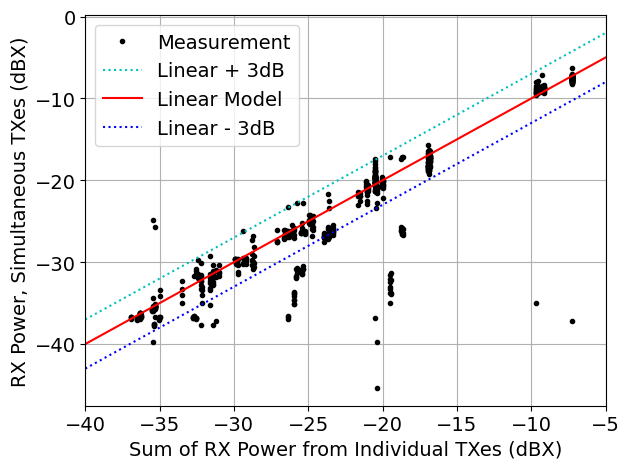

In [ ]:
plt.figure()
plt.plot(10*np.log10(sum_of_powers_1d), 10*np.log10(total_power_1d), 'k.', label="Measurement")
plt.plot([-40, -5], [-37,-2], 'c:', label='Linear + 3dB')
plt.plot([-40, -5], [-40,-5], 'r-', label='Linear Model')
plt.plot([-40, -5], [-43,-8], 'b:', label='Linear - 3dB')
plt.xlim([-40, -5])
plt.xlabel("Sum of RX Power from Individual TXes (dBX)", fontsize=14)
plt.ylabel("RX Power, Simultaneous TXes (dBX)", fontsize=14)
plt.legend(fontsize=14)
plt.tight_layout()
plt.grid()
plt.savefig('sum_vs_simultaneous.png')
plt.savefig('sum_vs_simultaneous.pdf')
